# `Débruitage d'image avec ondelettes`
*Important:* (http://gpeyre.github.io/numerical-tours/installation_python/ ce notebook utilise les ondelettes pour réaliser un débruitage d’image non linéaire.

`Modèles de dégradation`
__Objectif__ : retrouver l’image « parfaite » à partir de ses versions dégradées

Plusieurs étapes sont nécessaires pour y arriver
- Définir un modèle mathématique qui relie l’image observée à l’image désirée (modèle direct)
- Trouver (estimer) les éventuels paramètres du modèles
- Inverser le modèle direct pour estimer l’image désirée


In [7]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from nt_solutions.denoisingwav_2_wavelet_2d import exo1

### `Débruitage d'image`
On considère un modèle génératif simple d’images bruitées 
- $F = f_0+W$ où $f_0 \in \mathcal{R}^N$ est une image déterministe de $N$ pixels, 
- $W$ un bruit blanc gaussien distribué selon $\mathcal{N}(0,\sigma^2 \text{I}_N)$, 
- $\sigma^2$ est la variance du bruit.

L’objectif de cette méthode de débruitage est de : 
- définir un estimateur $\tilde F$ de $f_0$ qui ne dépend que de $F$, 
- c’est‑à‑dire $\tilde F = \phi(F)$ où $\phi : \mathcal{R}^N \rightarrow \mathcal{R}^N$ est une application potentiellement non linéaire.

On remarque que tandis que :
- $f_0$ est une image déterministe, 
- $F$ and $\tilde F$ sont toutes deux des variables aléatoires (d’où l’usage des lettres capitales).

Le but de ce débruitage est de réduire l’erreur, utilisant certaines connaissances a priori sur l’image (inconnue) $f_0$. 
- Une manière de mesurer cette erreur est de majorer le risque quadratique $\mathcal{E}_w(||{\tilde F - f_0}||^2)$, 
- où l’espérance est prise par rapport à la loi du bruit $W$.

#### `Chargement de l’image et ajout de bruit gaussien`
Chaque pixel aléatoire de $w$ selon une densité de probabilité Gaussienne est caractérisé par : $SNR =\Large \frac{\sigma^2{(f_0)}}{\sigma^2{(y)}}$
- dans le cas d'applications réelles, nous n’avons pas accès à l’image sous‑jacente $f_0$. 
- ici nous supposerons que: 
    - $f_0$ est connue, 
    - $f = f_0 + w\in \mathcal{R}^N$ est générée à partir d’une seule réalisation du bruit $w$ tirée de $W$. 
    - définissons l’image déterministe estimée par $\tilde f = \phi(f)$ qui est une réalisation du vecteur aléatoire $\tilde F$.
    - commençons par charger une image $f \in \mathcal{R}^N$ où $N=n \times n$ est le nombre de pixels.

In [10]:
n = 256
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)
print(f0.shape)
# normalise l'image, pour l’affichage et les paramètres (bruit, λ, etc.).
f0 = rescale(f0)

(256, 256)


In [11]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

Nous ajoutons un bruit Gaussian $w$ pour obtenir $f=f_0+w$ de variance $\sigma$.
 - Afficher l'image bruitée. 
 - Utiliser |clamp| pour saturer le résultat $[0,1]$ et éviter une perte du contraste à l'affichage.

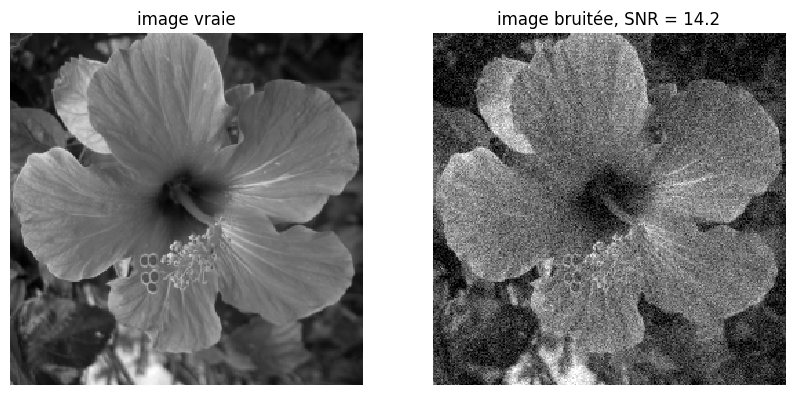

In [12]:
sigma = .08
y = f0 + np.random.randn(n, n)*sigma
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(y),f"image bruitée, SNR = {snr(f0,y):.3g}" , [1,2,2])

#### `Seuillage dur dans des bases d’ondelettes`
__`Un estimateur de débruitage non linéaire simple mais efficace s’obtient en`__ : 
- `seuillant les coefficients de` $f$ `dans une base orthogonale bien choisie` $\mathcal{B} = \{\psi_m\}_m$ de $\mathcal{R}^N$.
-  `en suite, nous nous concentrerons sur une base d’ondelettes, pour débruiter des images par morceaux régulières`.

L’opérateur de seuillage dur de seuil $T \geq 0$ appliqué à une image  $f$ est défini par :  
$$S_T^0(f)=\sum_{|\langle{f},{\psi_m}\rangle|>T}\langle{f},{\psi_m}\rangle\psi_m = \sum_m s_T^0(\langle{f},{\psi_m}\rangle)\psi_m$$
 - où l’opérateur de seuillage dur scalaire est is : $ S_T^0(\alpha) = \left\{ \begin{array}{ll}  \alpha  \text{ si } |\alpha| \ge T\\ 0 \text{ sinon } \end{array} \right.$
 - l’estimateur de débruitage est défini par : $ \tilde f = S_T^0(f)$


Fixer la valeur du seuil et afficher la fonction $s_T^0(\alpha)$.

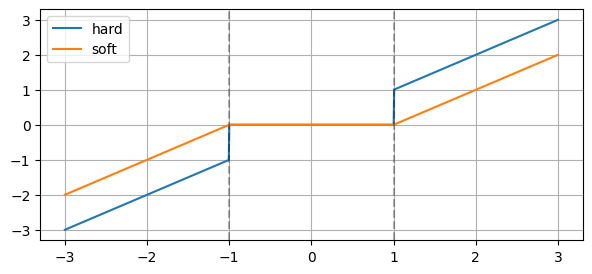

In [159]:
import numpy as np
import matplotlib.pyplot as plt

T = 1.0
alpha = np.linspace(-3, 3, 1000)

# Seuillage dur
hard = alpha * (np.abs(alpha) > T)

# Seuillage doux
# np.maximum : maximum élément par élément entre deux tableaux (ou tableau + scalaire).
soft = np.sign(alpha) * np.maximum(np.abs(alpha) - T, 0)

plt.figure(figsize=(7,3))
plt.plot(alpha, hard, label="hard")
plt.plot(alpha, soft, label="soft")
plt.axvline(T, color="k", ls="--", alpha=0.3)
plt.axvline(-T, color="k", ls="--", alpha=0.3)
plt.axis("tight")
plt.grid(True)
plt.legend()
plt.show()

### `Principe Transformée en ondelette discrète (DWT)`
`Version “classique, décimée” de la DWT, par opposition aux variantes non décimées/invariantes par translation`
- passer le signal / image dans un filtre passe-bas et un filtre passe-haut, 
- sous-échantillonner (décimation),
- répèter sur la sous-bande basse pour construire la décomposition multi-échelle.
<p align="center">
  <img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/2_Wavelet Denoising /Image Denoising with Wavelets/images/DWT.png" alt="DWT" width="350">
</p>

- `Paramètres pour la transformation orthogonal en ondelettes.` 
- `Calculer premièrement les coefficients en ondelettes de l'image bruitée y.`

$(J)$ est le **niveau de décomposition maximal** (ou niveau de résolution le plus grossier) utilisé dans la DWT.
- On part du signal original au **niveau 0**.  
- Niveau $(j = 1)$ : 
  - on applique les filtres (passe-bas/passe-haut) + décimation, 
  - on obtient les détails $(cD_1)$ (les variations les plus fines) et une approximation $(cA_1)$.  
- Niveau $(j = 2)$ : 
  - on recommence sur l’approximation $(cA_1)$, 
  - on obtient $(cD_2)$ (détails un peu plus grossiers) et $(cA_2)$.  
- …  
- Niveau $(j = J)$ : on obtient $(cD_J)$ et $(cA_J)$, qui est l’approximation la plus **grossière** du signal.
$(J)$ :
- indique **combien de fois** on applique l’étape de filtrage + sous-échantillonnage,  
- fixe l’échelle de la partie la plus “lisse” $(cA_J)$ (support large $( \sim 2^J ))$,  
- et détermine combien de blocs de détails tu as : $(cD_1, \dots, cD_J)$.

### `Décomposition multiniveau`

In [248]:
import pywt
import numpy as np
# Transformée décimée (options.ti = 0)
# y    : signal ou image
# wavelet='dbN', 'symN', 'haar'
wavelet = 'sym5'  # par ex., à adapter à ce que fait options.wavelet
w = pywt.Wavelet(wavelet)
J = pywt.dwt_max_level(data_len=len(y), filter_len=w.dec_len)
print(f"nombre maximal de niveaux de décomposition : {J}")
# 2D image : f is 2D array
coeffs_ti_2d = pywt.wavedec2(y, wavelet=wavelet, level=J)
# reconstruction correspondante
y_rec_2d = pywt.waverec2(coeffs_ti_2d, wavelet=wavelet)

nombre maximal de niveaux de décomposition : 4


wavedec2 : retourne la liste ordonnée de tableaux de coefficients, 
- où `n`représente le niveau de décomposition. 
- le premier élément ( cA_n) du résultat est le tableau des coefficients d'approximation 
- les éléments suivants ( cD_n $\dots$ cD_1) sont les tableaux des coefficients de détail.

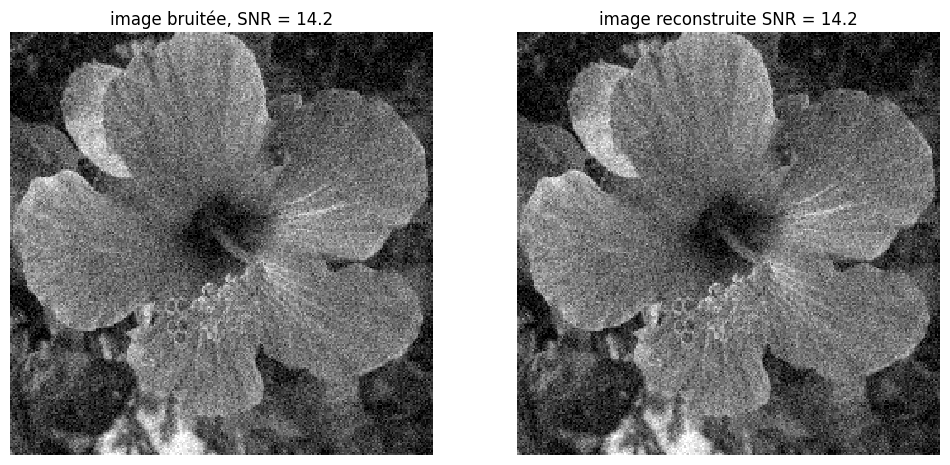

In [246]:
plt.figure(figsize=(12, 12))
imageplot(clamp(y),f"image bruitée, SNR = {snr(f0,y):.3g}" , [1,2,1])
imageplot(clamp(y_rec_2d),f"image reconstruite SNR = {snr(f0,y_rec_2d):.3g}",[1,2,2])

- Le SNR est (presque) le même car pour l’instant nous effectuons DWT → IDWT sans modification des coefficients. 
- C’est une transformée orthogonale/biorthogonale à reconstruction parfaite, donc $y_{rec}≈y$ à l’erreur numérique près.
- Choix du seuil T de type VisuShrink $T=\sigma \sqrt{2\log N}$ 

In [240]:
import numpy as np
import pywt

def estimate_sigma(detail_coeffs):
    # estimation robuste de σ à partir d'une sous-bande de détail
    # (MAD / 0.6745, classique Donoho-Johnstone)
    cH, cV, cD = detail_coeffs
    detail = np.concatenate([cH.ravel(), cV.ravel(), cD.ravel()])
    median = np.median(np.abs(detail))
    return median / 0.6745

def denoise_wavelet2D_visu(y, wavelet='sym13', J=3, mode='hard'):
    # décomposition
    coeffs = pywt.wavedec2(y, wavelet=wavelet, level=J)

    # estimation du bruit à partir du premier niveau de détails
    sigma = estimate_sigma(coeffs[-1])
    N = y.size
    T = sigma * np.sqrt(2 * np.log(N))  # seuil VisuShrink

    cA = coeffs[0]
    details = coeffs[1:]

    # seuillage sur toutes les sous-bandes de détails
    new_details = []
    for (cH, cV, cD) in details:
        cH_t = pywt.threshold(cH, T, mode=mode)
        cV_t = pywt.threshold(cV, T, mode=mode)
        cD_t = pywt.threshold(cD, T, mode=mode)
        new_details.append((cH_t, cV_t, cD_t))

    coeffs_thresh = [cA] + new_details
    y_rec = pywt.waverec2(coeffs_thresh, wavelet=wavelet)
    return y_rec, T, sigma

nombre maximal de niveaux de décomposition : 4, T : 0.3837, sigma : 0.0815


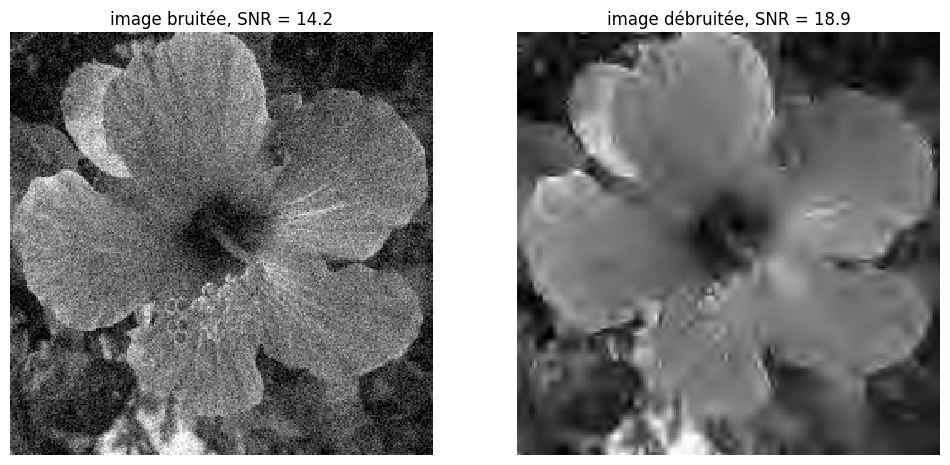

In [247]:
y_rec_2d, T, sigma = denoise_wavelet2D_visu(y, wavelet=wavelet, J=J, mode='hard')
print(f"nombre maximal de niveaux de décomposition : {J}, T : {T:.4f}, sigma : {sigma:.4f}")

plt.figure(figsize=(12, 12))
imageplot(clamp(y), f"image bruitée, SNR = {snr(f0, y):.3g}", [1, 2, 1])
imageplot(clamp(y_rec_2d), f"image débruitée, SNR = {snr(f0, y_rec_2d):.3g}", [1, 2, 2])
plt.show()

Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base (ondelettes et fonctions d’échelle).
`Ce que représente un coefficient`
Pour chaque échelle j et position k :
- $\phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle j et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

Mathématiquement, nous avons une décomposition du type : $f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$
- où $\phi_{J,k}$ sont les fonctions d’échelle et $\psi_{j,k}$ les ondelettes.
- le premier bloc que tu concatènes correspond à cA_J (approximation grossière).
- les blocs suivants sont cD_1, cD_2, ..., cD_J (détails de plus en plus grossiers suivant l'ordre).

_`Affichage des coefficients de débruitage :`_
La décimation, dans Discrete Wavelet Transform, est le fait de jeter un échantillon sur deux (ou plus généralement, un échantillon sur M pour un facteur de décimation M).
Pour un niveau de décomposition :
- On filtre le signal avec un passe-bas h → on obtient un signal “lissé”.
- On filtre avec un passe-haut g → on obtient un signal “détails”.
- Sur chacun des deux résultats, on ne garde qu’un échantillon sur deux :
   - $a_1[n]=(f∗h)[2n]$
   - $d_1[n]=(f∗g)[2n]$
_`Remarque :`_ 
- DWT “classique” (celle de wavedec) = filtrage + décimation → pas invariante par translation.
- Transformée stationnaire (SWT, swt) = filtrage sans décimation → invariance par translation, 
   - mais plus de coefficients (redondance).  

/Users/asriel/miniconda3/envs/DDFM/lib/python3.8/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


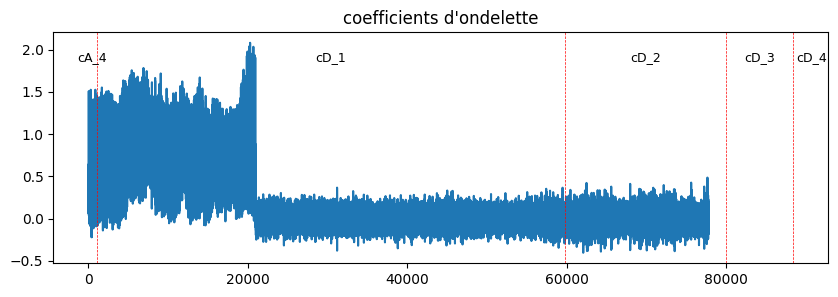

In [158]:
plt.figure(figsize=(10,3))
plt.plot(x)
plt.title("coefficients d'ondelette")

# Jmin : niveau minimal
# J    : niveau maximal (par ex. J = Jmin + 1 comme dans l'appel MATLAB)

Jmin = 4
coeffs_ti_2d = pywt.wavedec2(y, wavelet=wavelet, level=Jmin+1)
cA_J, *details = coeffs_ti_2d
details = details[::-1]
blocs = [np.ravel(cA_J)] + [np.ravel(d) for d in details]
labels = [f"cA_{J}"] + [f"cD_{j}" for j in range(1, J+1)]

# positions de séparation + annotations
pos = 0
labels = [f"cA_{Jmin}"] + [f"cD_{j}" for j in range(1, Jmin+1)]

for b, lab in zip(blocs, labels):
    L = len(b)
    x_center = pos + L/2
    # ligne verticale au début du bloc (sauf le tout premier)
    if pos > 0:
        plt.axvline(pos, color='r', linestyle='--', linewidth=0.5)
    # texte au milieu du bloc
    plt.text(x_center, plt.ylim()[1]*0.9, lab,
             ha='center', va='top', fontsize=9, color='k')
    pos += L

plt.axis('tight')
plt.show()


Sur le graphe, nous voyons la concaténation des blocs $([cA_J, cD_1, cD_2, \dots, cD_J])$ :
- CA_4: très “énergétique”, correspond aux **coefficients d’approximation** $(cA_J)$ (contenu lisse à grande échelle).  
- Chaque zone séparée par une ligne verticale rouge correspond à une **bande de détails** $(cD_j)$ 
- à une échelle donnée : 
   - plus on va vers la droite, plus l’échelle est **grossière** (variations plus larges).  
- La partie centrale “plate” proche de 0, avec beaucoup de petites oscillations, montre que la plupart des coefficients sont petits (souvent assimilables à du bruit), ce qui justifie le seuillage pour le débruitage.

In [86]:
# 2D image : f is 2D array
coeffs_ti_2d = pywt.wavedec2(y, wavelet=wavelet, level=Jmin+1)
# reconstruction correspondante
y_rec_2d = pywt.waverec2(coeffs_ti_2d, wavelet=wavelet)

In [57]:
import matplotlib.pyplot as plt

def plot_wavelet_2d(coeffs):
    """
    coeffs : [cA_J, (cH_J, cV_J, cD_J), ..., (cH_1, cV_1, cD_1)]
    comme renvoyé par pywt.wavedec2
    """
    cA_J = coeffs[0]
    details = coeffs[1:]  # liste de tuples (cH_j, cV_j, cD_j)

    n_levels = len(details)

    fig, axes = plt.subplots(n_levels + 1, 4, figsize=(10, 2.5*(n_levels+1)))
    # première ligne : approximation
    ax = axes[0, 0]
    im = ax.imshow(cA_J, cmap="gray")
    ax.set_title("cA_J")
    ax.axis("off")
    for j in range(1, 4):
        axes[0, j].axis("off")

    # lignes suivantes : détails par niveau
    for i, (cH, cV, cD) in enumerate(details, start=1):
        for ax, img, title in zip(axes[i], [cH, cV, cD, None],
                                  ["cH", "cV", "cD", ""]):
            ax.axis("off")
            if img is not None:
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{title}_{n_levels-i+1}")

    plt.tight_layout()
    return fig


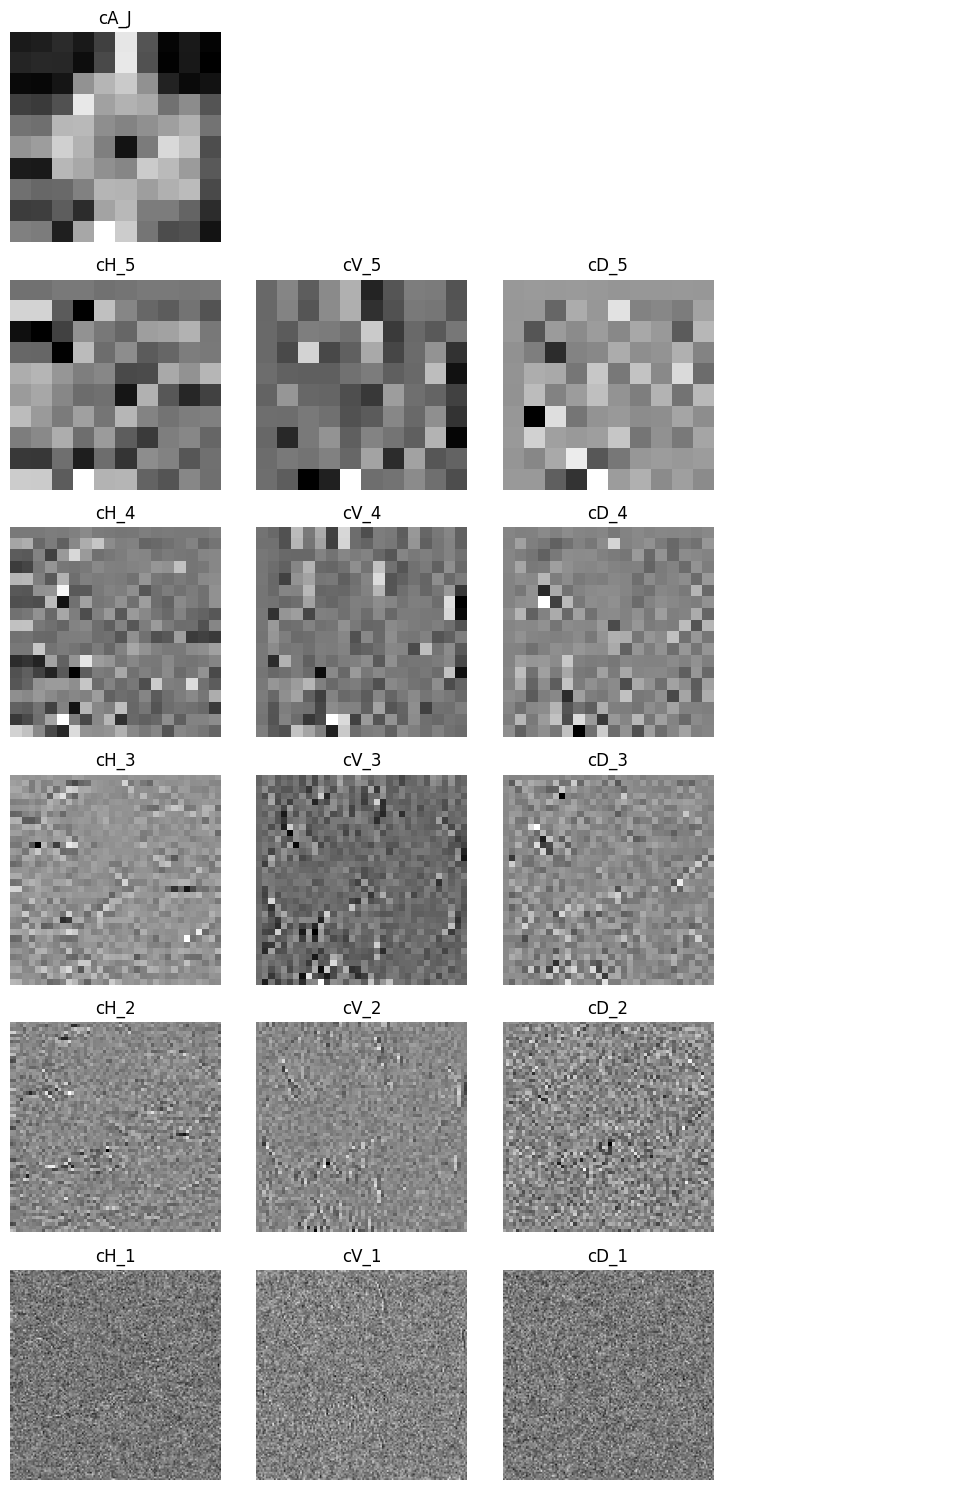

In [58]:
coeffs2 = pywt.wavedec2(y, wavelet="db2", level=Jmin+1)
plot_wavelet_2d(coeffs2)
plt.show()

Select the threshold value, that should be proportional to the noise
level $\si$.

In [ ]:
T = 3*sigma

Hard threshold the coefficients below the noise level to obtain $a_T(m)=s_T^0(a_m)$.

In [ ]:
aT = a .* (abs(a) >T)

Display the thresholded coefficients.

In [ ]:
plot_wavelet(aT, Jmin)

Reconstruct the image $\tilde f$ from these noisy coefficients.

In [ ]:
fHard = perform_wavelet_transf(aT, Jmin, -1, options)

Display the denoising result.

In [ ]:
imageplot(clamp(fHard), strcat(['Hard denoising, SNR = ' num2str(snr(f0, fHard), 3)]))

Wavelet Denoising with Soft Thesholding
---------------------------------------
The estimated image $\tilde f$ using hard thresholding.
suffers from many artifacts. It is
possible to improve the result by using soft thresholding,
defined as
$$ \tilde f = S_T^1(f) = \sum_m s_T^1(\dotp{f}{\psi_m}) \psi_m $$
$$
      \qwhereq
      s_T^1(\alpha) = \max\pa{0, 1 - \frac{T}{\abs{\alpha}}}\alpha.
$$



Display the soft thresholding function $s_T^1(\al)$.

In [ ]:
T = 1
alpha = linspace(-3, 3, 1000)
alphaT = max(1-T./ abs(alpha), 0).*alpha

plot(alpha, alphaT)
axis tight

Select the threshold.

In [ ]:
T = 3/ 2*sigma

Perform the soft thresholding.

In [ ]:
aT = perform_thresholding(a, T, 'soft')

To slightly improve the soft thresholding performance, we do not
threshold the coefficients corresponding to coarse scale wavelets.

In [ ]:
aT(1: 2^Jmin, 1: 2^Jmin) = a(1: 2^Jmin, 1: 2^Jmin)

Re-construct the soft thresholding estimator $\tilde f$.

In [ ]:
fSoft = perform_wavelet_transf(aT, Jmin, -1, options)

Display the soft thresholding denoising result.

In [ ]:
imageplot(clamp(fSoft), strcat(['Soft denoising, SNR = ' num2str(snr(f0, fSoft), 3)]))

One can prove that if the non-linear approximation error
$ \norm{f_0-S_T(f_0)}^2 $ decays fast toward zero when
$T$ decreases, then the quadratic risk
$ \EE_w( \norm{f-S_T(f)}^2 ) $ also decays fast to zero
when $\si$ decays. For this result to hold, it is required
to select the threshold value according to the universal threshold rule
$$ T = \si \sqrt{2\log(N)}. $$

__Exercise 1__

Determine the best threshold $T$ for both hard and soft thresholding.
Test several $T$ values in $[.8*\sigma, 4.5\sigma$,
and display the empirical SNR $-10\log_{10}(\norm{f_0-\tilde f}/\norm{f_0})$
What can you conclude from these results ?
Test with another image.

In [ ]:
solutions.exo1()

In [ ]:
## Insert your code here.

Translation Invariant Denoising with Cycle Spinning
---------------------------------------------------
Orthogonal wavelet transforms are not translation invariant.
It means that the processing of an image and of a translated version of
the image give different results.


Any denoiser can be turned into a translation invariant denoiser by
performing a cycle spinning. The denoiser is applied to several shifted
copies of the image, then the resulting denoised image are shifted back
to the original position, and the results are averaged.


This corresponds to defining the estimator as
$$ \tilde f = \frac{1}{M} \sum_{i=1}^{M}
      T_{-\de_i} \circ S_T(f) \circ T_{\de_i}$$
where $S_T$ is either the hard or soft thresholding,
and $T_\de(f)(x) = f(x-\de)$ is the translation operator,
using periodic boundary conditions.
Here $(\de_i)_i$ is a set of $M$ discrete translation. Perfect invariance
is obtained by using all possible $N$ translatation, but
usually a small number $M \ll N$ of translation is used to obtain approximate
invariance.



Number $m$ of translations along each direction
so that $M = m^2$.

In [ ]:
m = 4

Generate a set of shifts $(\de_i)_i$.

In [ ]:
[dY, dX] = meshgrid(0: m-1, 0: m-1)
delta = [dX(: ) dY(: )]'

To avoid storing all the translates in memory, one can perform a
progressive averaging of the translates by defining $f^{(0)}=0$ and
then
$$ \forall\, i=1,\ldots,M, \quad f^{(i)} = \pa{1-\frac{i}{n}} f^{(i-1)} +
      \frac{i}{n} T_{-\de_i} \circ S_T(f) \circ T_{\de_i}  $$
One then has $\tilde f = f^{(M)} $ after $M$ steps.


Initialize the denoised image $f^{(0)}=0$.

In [ ]:
fTI = zeros(n, n)

Initialize the index $i$ that should run in $1,\ldots,m^2$

In [ ]:
i = 1

Apply the shift, using circular boundary conditions.

In [ ]:
fS = circshift(f, delta(: , i))

Apply here the denoising to |fS|.

In [ ]:
a = perform_wavelet_transf(fS, Jmin, 1, options)
aT = perform_thresholding(a, T, 'hard')
fS = perform_wavelet_transf(aT, Jmin, -1, options)

After denoising, do the inverse shift.

In [ ]:
fS = circshift(fS, -delta(: , i))

Accumulate the result to obtain at the end the denoised image that
averahe the translated results.

In [ ]:
fTI = (i-1)/ i*fTI + 1/ i*fS

__Exercise 2__

Perform the cycle spinning denoising by iterating on $i$.

In [ ]:
solutions.exo2()

In [ ]:
## Insert your code here.

__Exercise 3__

Study the influence of the number $m$ of shift on the denoising
quality.

In [ ]:
solutions.exo3()

In [ ]:
## Insert your code here.

Translation Invariant Wavelet Transform
---------------------------------------
Another way to achieve translation invariance, which is equivalent to
performing cycle spinning, is to replace the orthogonal wavelet
basis $\Bb = \{\psi_m\}_{m=0}^{N-1}$ by a redundant translation
invariant wavelet frame
$$ \Dd = \enscond{ \psi_m(\cdot-\de) }{ m = 0,\ldots,N-1, \de \in \{0,\ldots,n-1\}^2 }. $$


One can prove that there is actually only $P = N\log_2(N)$ atoms in this
dictionary, that we note $\De = \{\tilde \psi_k\}_{k=0}^{P-1}$.


One can furthermore define weights $\la_k>0$ so that the
following reconstruction formula holds (pseudo-invers reconstruction)
$$ f = \sum_k \la_k \dotp{f}{\tilde \psi_k} \tilde \psi_k. $$


For Scilab, we need to extend a little the available memory.


_Important:_ If you are using an old version (<v5)
of Scilab, then use |extend_stack_size(4,1)| instead.

In [ ]:
extend_stack_size(4)

The invariant transform is obtained using the same function, by
activating the switch |options.ti=1|.

In [ ]:
options.ti = 1
a = perform_wavelet_transf(f0, Jmin, + 1, options)

|a(:,:,1)| corresponds to the low scale residual.
Each |a(:,:,3*j+k+1)| for k=1:3 (orientation) corresponds to a scale of wavelet coefficient, and has
the same size as the original image.

In [ ]:
i = 0
for j in 1: 2:
for k in 1: 3:
        i = i + 1
        imageplot(a(: , : , i + 1), strcat(['Scale = ' num2str(j) ' Orientation = ' num2str(k)]), 2, 3, i)

Translation Invariant Wavelet Denoising
---------------------------------------
A translation invariant thresholding estimator is defined as
$$ \tilde f = \sum_k \la_k s_T(\dotp{f}{\tilde \psi_k}) \tilde \psi_k, $$
where $s_T$ is either the soft or the hard thresholding mapping.


This estimator is equal to the cycle spinning estimator when using the
full set $M=N$ of translates. It is however much faster to compute
because computing the whole set of $N\log_2(N)$ inner products $(\dotp{f}{\tilde\psi_k})_k$
is obtained with the fast a trou algorithm in $O(N\log_2(N))$
operations.
Similarely, a fast inverse transform with the same complexity allows one
to reconstruct $\tilde f$ from the set of thresholded coefficients.


First we compute the translation invariant wavelet transform

In [ ]:
options.ti = 1
a = perform_wavelet_transf(f, Jmin, + 1, options)

Then we threshold the set of coefficients.

In [ ]:
T = 3.5*sigma
aT = perform_thresholding(a, T, 'hard')

Display noisy wavelets coefficients at a given fixed scale.

In [ ]:
J = size(a, 3)-5

imageplot(a(: , : , J), 'Noisy coefficients')

Display thresholded wavelets coefficients

In [ ]:
imageplot(aT(: , : , J), 'Thresholded coefficients')

We can now reconstruct

In [ ]:
fTI = perform_wavelet_transf(aT, Jmin, -1, options)

Display the denoising result $\tilde f$.

In [ ]:
imageplot(clamp(fTI), strcat(['Hard invariant, SNR = ' num2str(snr(f0, fTI), 3)]))

__Exercise 4__

Determine the best threshold $T$ for both hard and soft thresholding,
but now in the translation invariant case. What can you conclude ?

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.